## Modified introduction using forex data

This is the trading rule example shown in [the introduction](https://github.com/robcarver17/pysystemtrade/blob/master/docs/introduction.md) but modified to use Interactive Brokers instead of CSV files as data source.  

IB requires a minimum equity and a monthly subscription to provide historical data on future contracts.  This example was modified to use FX prices instead futures to make it runnable with free unfunded paper trading accounts.  Note that Rob [does not recommend trading FX spot data with IB due to their high fees](https://github.com/robcarver17/pysystemtrade/issues/517#issuecomment-1010770678).

First, import the required packages and initialize ib_insync.  

In [3]:
from sysbrokers.IB.ib_connection import connectionIB
from sysbrokers.IB.ib_Fx_prices_data import ibFxPricesData

from ib_insync import util
util.startLoop() #only required when running inside a notebook

Connecting to Interactive Brokers gateway...

In [4]:
conn = connectionIB(314, account="U16129998")
conn

IB broker connection{'ipaddress': '127.0.0.1', 'port': 4002, 'client': 314}

See what fx instruments we have configured.  These are configured in `sysbrokers/IB/ib_config_spot_FX.csv`

In [5]:
from sysdata.data_blob import dataBlob
ibfxpricedata = ibFxPricesData(conn, dataBlob())
ibfxpricedata.get_list_of_fxcodes()

['AUDUSD',
 'CADUSD',
 'CHFUSD',
 'EURUSD',
 'GBPUSD',
 'HKDUSD',
 'JPYUSD',
 'KRWUSD',
 'CNHUSD',
 'SGDUSD',
 'MXPUSD',
 'SEKUSD']

Now we select one instrument (`EURUSD`) and try to fetch historical data for it.

In [7]:
ibfxpricedata.get_fx_prices('EURUSD')
ibfxpricedata.get_fx_prices('HKDUSD')

2025-03-30 19:14:10 DEBUG ibFxPricesData {'currency_code': 'EURUSD'} Updating log attributes
2025-03-30 19:14:10 DEBUG ibFxPricesData Log attributes reset
2025-03-30 19:14:10 DEBUG ibFxPricesData {'currency_code': 'EURUSD'} Downloaded 259 prices
2025-03-30 19:14:10 DEBUG ibFxPricesData {'currency_code': 'USDHKD'} Updating log attributes
2025-03-30 19:14:10 DEBUG ibFxPricesData {'currency_code': 'USDHKD'} Pausing 0.471337 seconds to avoid pacing violation
2025-03-30 19:14:12 DEBUG ibFxPricesData Log attributes reset
2025-03-30 19:14:12 DEBUG ibFxPricesData {'currency_code': 'HKDUSD'} Downloaded 259 prices


index
2024-03-29 23:00:00    0.127793
2024-04-01 23:00:00    0.127782
2024-04-02 23:00:00    0.127728
2024-04-03 23:00:00    0.127733
2024-04-04 23:00:00    0.127734
                         ...   
2025-03-24 23:00:00    0.128631
2025-03-25 23:00:00    0.128622
2025-03-26 23:00:00    0.128598
2025-03-27 23:00:00    0.128608
2025-03-28 23:00:00    0.128560
Name: FINAL, Length: 259, dtype: float64

Data can also be indexed as a python dict:

In [8]:
ibfxpricedata['HKDUSD']

2025-03-30 19:14:56 DEBUG ibFxPricesData {'currency_code': 'USDHKD'} Updating log attributes
2025-03-30 19:14:56 DEBUG ibFxPricesData Log attributes reset
2025-03-30 19:14:56 DEBUG ibFxPricesData {'currency_code': 'HKDUSD'} Downloaded 259 prices


index
2024-03-29 23:00:00    0.127793
2024-04-01 23:00:00    0.127782
2024-04-02 23:00:00    0.127728
2024-04-03 23:00:00    0.127733
2024-04-04 23:00:00    0.127734
                         ...   
2025-03-24 23:00:00    0.128631
2025-03-25 23:00:00    0.128622
2025-03-26 23:00:00    0.128598
2025-03-27 23:00:00    0.128608
2025-03-28 23:00:00    0.128560
Name: FINAL, Length: 259, dtype: float64

Create the trading rule

In [33]:
import pandas as pd
from sysquant.estimators.vol import robust_vol_calc


def calc_ewmac_forecast(price, Lfast, Lslow=None):
    """
    Calculate the ewmac trading rule forecast, given a price and EWMA speeds Lfast, Lslow and vol_lookback

    """
    if Lslow is None:
        Lslow = 4 * Lfast

    ## We don't need to calculate the decay parameter, just use the span directly
    fast_ewma = price.ewm(span=Lfast).mean()
    slow_ewma = price.ewm(span=Lslow).mean()
    raw_ewmac = fast_ewma - slow_ewma

    vol = robust_vol_calc(price.diff())

    return raw_ewmac / vol

Run a forecast with the previous rule

In [34]:
price=ibfxpricedata['EURUSD']
ewmac=calc_ewmac_forecast(price, 32, 128)
ewmac.tail(5)

2025-03-25 18:30:10 DEBUG ibFxPricesData {'currency_code': 'EURUSD'} Updating log attributes
2025-03-25 18:30:10 DEBUG ibFxPricesData {'currency_code': 'EURUSD'} Pausing 0.434726 seconds to avoid pacing violation
2025-03-25 18:30:10 DEBUG ibFxPricesData Log attributes reset
2025-03-25 18:30:10 DEBUG ibFxPricesData {'currency_code': 'EURUSD'} Downloaded 259 prices


index
2025-03-19 23:00:00    0.757002
2025-03-20 23:00:00    0.887204
2025-03-21 23:00:00    0.998143
2025-03-24 23:00:00    1.103367
2025-03-25 23:00:00    1.224477
Name: FINAL, dtype: float64

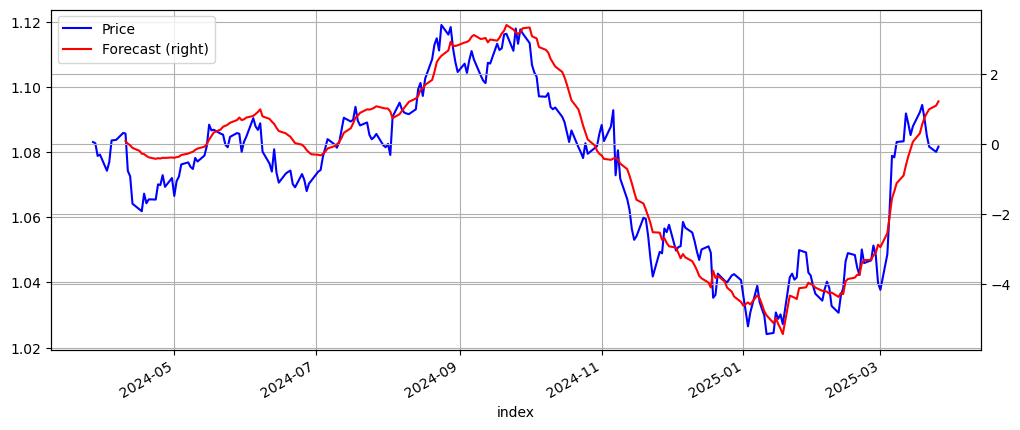

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

ax1 = price.plot(color='blue', grid=True, label='Price')
ax2 = ewmac.plot(color='red', grid=True, secondary_y=True, label='Forecast')

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()


plt.legend(h1+h2, l1+l2, loc=2)
plt.show()

The original introduction jumps directly to "Did we make any money?".  
I would like to see here the orders that were triggered by this forecast, but instead we jump directly into P&L.  Still, these are the P&L numbers for this forecast and data:

In [36]:
from systems.accounts.account_forecast import pandl_for_instrument_forecast
account = pandl_for_instrument_forecast(forecast = ewmac, price = price)
account.percent.stats()

[[('min', '-1.639'),
  ('max', '1.162'),
  ('median', '-0.002287'),
  ('mean', '-0.01326'),
  ('std', '0.2594'),
  ('skew', '-0.8752'),
  ('ann_mean', '-3.395'),
  ('ann_std', '4.15'),
  ('sharpe', '-0.8182'),
  ('sortino', '-0.9182'),
  ('avg_drawdown', '-1.242'),
  ('time_in_drawdown', '0.9272'),
  ('calmar', '-0.7425'),
  ('avg_return_to_drawdown', '-2.733'),
  ('avg_loss', '-0.1599'),
  ('avg_gain', '0.159'),
  ('gaintolossratio', '0.9942'),
  ('profitfactor', '0.8384'),
  ('hitrate', '0.4575'),
  ('t_stat', '-0.8261'),
  ('p_value', '0.4095')],
 ('You can also plot / print:',
  ['rolling_ann_std', 'drawdown', 'curve', 'percent'])]

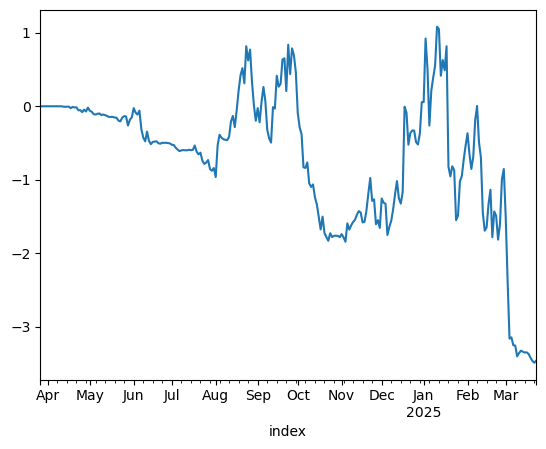

In [37]:
account.curve().plot()
plt.show()

In [38]:
conn.close_connection()

2025-03-25 18:30:11 DEBUG connectionIB {'type': 'connectionIB', 'broker': 'IB', 'clientid': 314} Terminating {'ipaddress': '127.0.0.1', 'port': 4002, 'client': 314}
